In [2]:
import requests
import json
from rdflib import ConjunctiveGraph
from tqdm.notebook import tqdm

In [2]:
# Get all workflow URLs from the sitemap https://workflowhub.eu/sitemaps/workflows.xml
# fetch the sitemap and parse it to extract workflow URLs
response = requests.get("https://workflowhub.eu/sitemaps/workflows.xml")
sitemap_data = response.text
# write file on disk
with open("workflows_sitemap.xml", "w") as f:
    f.write(sitemap_data)

In [9]:
import xml.etree.ElementTree as ET


def parse_sitemap(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Detect namespace if present
    ns_uri = root.tag.split("}")[0].strip("{") if "}" in root.tag else ""
    ns = {"sm": ns_uri} if ns_uri else {}

    urls = []

    # Case 1: regular sitemap (<urlset>)
    if root.tag.endswith("urlset"):
        for u in root.findall("sm:url" if ns else "url", ns):
            loc = u.find("sm:loc" if ns else "loc", ns)
            lastmod = u.find("sm:lastmod" if ns else "lastmod", ns)
            urls.append(
                {
                    "loc": loc.text.strip() if loc is not None and loc.text else None,
                    "lastmod": (
                        lastmod.text.strip()
                        if lastmod is not None and lastmod.text
                        else None
                    ),
                }
            )

    # Case 2: sitemap index (<sitemapindex>)
    elif root.tag.endswith("sitemapindex"):
        for s in root.findall("sm:sitemap" if ns else "sitemap", ns):
            loc = s.find("sm:loc" if ns else "loc", ns)
            lastmod = s.find("sm:lastmod" if ns else "lastmod", ns)
            urls.append(
                {
                    "sitemap": (
                        loc.text.strip() if loc is not None and loc.text else None
                    ),
                    "lastmod": (
                        lastmod.text.strip()
                        if lastmod is not None and lastmod.text
                        else None
                    ),
                }
            )

    return urls


data = parse_sitemap("workflows_sitemap.xml")
print("entries:", len(data))
print(data[:3])

entries: 1467
[{'loc': 'https://workflowhub.eu/workflows/2', 'lastmod': '2020-04-10T10:20:13+00:00'}, {'loc': 'https://workflowhub.eu/workflows/3', 'lastmod': '2020-06-30T08:05:01+00:00'}, {'loc': 'https://workflowhub.eu/workflows/4', 'lastmod': '2020-04-10T12:06:00+00:00'}]


In [10]:
# save the workflow URLs in a json file
#json.dump(data, open("workflow_urls.json", "w"), indent=2)


In [11]:
def retrieve_rdf(url):
    FC_get_md = (
        "https://fair-checker.france-bioinformatique.fr/api/inspect/get_rdf_metadata"
    )
    kg = ConjunctiveGraph()
    res = requests.get(url=FC_get_md, params={"url": url})
    try:
        kg.parse(data=res.text, format="json-ld")
    except Exception as e:
        print(e)
    print(f"Loaded {len(kg)} RDF triples from {url}")
    return kg


data = json.load(open("workflow_urls.json", "r"))

merged_kg = ConjunctiveGraph()
for url in data[1390:1395]:
    print(url)
    kg = retrieve_rdf(url["loc"])
    print(f"KG has {len(kg)} triples")
    merged_kg += kg

print(f"Final merged KG has {len(merged_kg)} triples")

/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_73333/2492634495.py:16: DeprecationWarning: ConjunctiveGraph is deprecated, use Dataset instead.
  merged_kg = ConjunctiveGraph()
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_73333/2492634495.py:5: DeprecationWarning: ConjunctiveGraph is deprecated, use Dataset instead.
  kg = ConjunctiveGraph()


{'loc': 'https://workflowhub.eu/workflows/2073', 'lastmod': '2026-02-02T13:25:14+00:00'}
Loaded 33 RDF triples from https://workflowhub.eu/workflows/2073
KG has 33 triples
{'loc': 'https://workflowhub.eu/workflows/2074', 'lastmod': '2026-02-09T07:45:30+00:00'}
Loaded 51 RDF triples from https://workflowhub.eu/workflows/2074
KG has 51 triples
{'loc': 'https://workflowhub.eu/workflows/2075', 'lastmod': '2026-02-04T02:50:11+00:00'}
Loaded 19 RDF triples from https://workflowhub.eu/workflows/2075
KG has 19 triples
{'loc': 'https://workflowhub.eu/workflows/2076', 'lastmod': '2026-02-04T02:50:13+00:00'}
Loaded 19 RDF triples from https://workflowhub.eu/workflows/2076
KG has 19 triples
{'loc': 'https://workflowhub.eu/workflows/2077', 'lastmod': '2026-02-04T02:50:19+00:00'}
Loaded 19 RDF triples from https://workflowhub.eu/workflows/2077
KG has 19 triples
Final merged KG has 120 triples


In [12]:
merged_kg.serialize(destination="dump_wf_hub.ttl", format="turtle")

<Graph identifier=N427de0229a0b408997cdbbf88df51747 (<class 'rdflib.graph.ConjunctiveGraph'>)>

In [29]:
data = json.load(open("workflow_urls.json", "r"))
URLS = []
for url in data:
    print(url)
    URLS.append(url)


{'loc': 'https://workflowhub.eu/workflows/2', 'lastmod': '2020-04-10T10:20:13+00:00'}
{'loc': 'https://workflowhub.eu/workflows/3', 'lastmod': '2020-06-30T08:05:01+00:00'}
{'loc': 'https://workflowhub.eu/workflows/4', 'lastmod': '2020-04-10T12:06:00+00:00'}
{'loc': 'https://workflowhub.eu/workflows/5', 'lastmod': '2020-04-10T12:32:21+00:00'}
{'loc': 'https://workflowhub.eu/workflows/6', 'lastmod': '2020-04-10T12:44:38+00:00'}
{'loc': 'https://workflowhub.eu/workflows/7', 'lastmod': '2020-04-10T12:52:21+00:00'}
{'loc': 'https://workflowhub.eu/workflows/8', 'lastmod': '2020-04-10T12:54:10+00:00'}
{'loc': 'https://workflowhub.eu/workflows/9', 'lastmod': '2020-04-10T13:00:36+00:00'}
{'loc': 'https://workflowhub.eu/workflows/10', 'lastmod': '2020-04-10T13:30:37+00:00'}
{'loc': 'https://workflowhub.eu/workflows/11', 'lastmod': '2022-03-30T16:37:14+00:00'}
{'loc': 'https://workflowhub.eu/workflows/12', 'lastmod': '2020-04-10T14:17:44+00:00'}
{'loc': 'https://workflowhub.eu/workflows/13', 'las

In [ ]:
FC_all_metrics_url = "https://fair-checker.france-bioinformatique.fr/api/check/legacy/metrics_all"

import time
from json import JSONDecodeError

import pandas as pd
import requests
from tqdm.notebook import tqdm

df = pd.DataFrame()
rows = []

cpt = 0
for url in URLS:
    #for u in tqdm(URLs):
    u = url["loc"]
    print("Evaluating " + u)
    start = time.time()
    res = requests.get(url=FC_all_metrics_url, params={"url": u})
    eval_in_sec = time.time() - start

    try:
        evaluations = res.json()
        row = {"URL": u}

        # iterating over all evaluation results
        for e in evaluations:
            #print(e)
            row[e["metric"]] = int(e["score"])
        # row["duration (s)"] = round(eval_in_sec, 2)
        # print(row)
        rows.append(row)
        cpt += 1
        if cpt % 2 == 0:
            print(f"processed {cpt / len(URLS) * 100:.2f}% of URLs")
    except JSONDecodeError as error:
        print("Cannot get FAIR assesment for " + u)
        print(res.text)


Evaluating https://workflowhub.eu/workflows/2


In [14]:
df = pd.DataFrame.from_records(rows)
df

,URL,F1A,F1B,F2A,F2B,A1.1,A1.2,I1,I2,I3,R1.1,R1.2,R1.3
0,https://workflowhub.eu/workflows/2073,2,2,1,1,2,2,1,1,2,2,2,1
1,https://workflowhub.eu/workflows/2074,2,2,1,1,2,2,1,1,2,2,2,1
2,https://workflowhub.eu/workflows/2075,2,0,1,1,2,2,1,1,2,2,2,1
3,https://workflowhub.eu/workflows/2076,2,0,1,1,2,2,1,1,2,2,2,1
4,https://workflowhub.eu/workflows/2077,2,0,1,1,2,2,1,1,2,2,2,1


In [20]:
from IPython.display import display, Markdown

df = pd.DataFrame.from_records(rows)

df["F_score"] = df.apply(
    lambda row: round((row["F1A"] + row["F1B"] + row["F2A"] + row["F2B"]) * 100 / 8, 1),
    axis=1,
)
df["A_score"] = df.apply(
    lambda row: round((row["A1.1"] + row["A1.2"]) * 100 / 4, 1), axis=1
)
df["I_score"] = df.apply(
    lambda row: round((row["I1"] + row["I2"] + row["I3"]) * 100 / 6, 1), axis=1
)
df["R_score"] = df.apply(
    lambda row: round((row["R1.1"] + row["R1.2"] + row["R1.3"]) * 100 / 6, 1), axis=1
)
# df['FAIR_score'] = df.apply(lambda row: round((row["F_score"] + row["A_score"] + row["I_score"] + row["R_score"])/4, 1), axis = 1)
df["FAIR_score"] = df.apply(
    lambda row: round(
        (
                row["F1A"]
                + row["F1B"]
                + row["F2A"]
                + row["F2B"]
                + row["A1.1"]
                + row["A1.2"]
                + row["I1"]
                + row["I2"]
                + row["I3"]
                + row["R1.1"]
                + row["R1.2"]
                + row["R1.3"]
        )
        * 100
        / 24,
        1,
    ),
    axis=1,
)

df.to_csv("wfhub-fc_evals-2026.csv")

md = df.to_markdown()
display(Markdown(md))

|    | URL                                   |   F1A |   F1B |   F2A |   F2B |   A1.1 |   A1.2 |   I1 |   I2 |   I3 |   R1.1 |   R1.2 |   R1.3 |   F_score |   A_score |   I_score |   R_score |   FAIR_score |
|---:|:--------------------------------------|------:|------:|------:|------:|-------:|-------:|-----:|-----:|-----:|-------:|-------:|-------:|----------:|----------:|----------:|----------:|-------------:|
|  0 | https://workflowhub.eu/workflows/2073 |     2 |     2 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |        75 |       100 |      66.7 |      83.3 |         79.2 |
|  1 | https://workflowhub.eu/workflows/2074 |     2 |     2 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |        75 |       100 |      66.7 |      83.3 |         79.2 |
|  2 | https://workflowhub.eu/workflows/2075 |     2 |     0 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |        50 |       100 |      66.7 |      83.3 |         70.8 |
|  3 | https://workflowhub.eu/workflows/2076 |     2 |     0 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |        50 |       100 |      66.7 |      83.3 |         70.8 |
|  4 | https://workflowhub.eu/workflows/2077 |     2 |     0 |     1 |     1 |      2 |      2 |    1 |    1 |    2 |      2 |      2 |      1 |        50 |       100 |      66.7 |      83.3 |         70.8 |

A1.1  A1.2  F1A   F1B    F2A   F2B   I1    I2    I3    R1.1  R1.2  R1.3
True  True  True  True   True  True  True  True  True  True  True  True    1
                                                                   True    1
                  False  True  True  True  True  True  True  True  True    1
                                                                   True    1
                                                                   True    1
Name: ones, dtype: int64


/Users/gaignard-a/miniconda3/envs/fc-p311/lib/python3.11/site-packages/upsetplot/plotting.py:795: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  styles["linewidth"].fillna(1, inplace=True)
/Users/gaignard-a/miniconda3/envs/fc-p311/lib/python3.11/site-packages/upsetplot/plotting.py:796: ChainedAssignmentError: A value is being set on a

ValueError: Invalid RGBA argument: nan

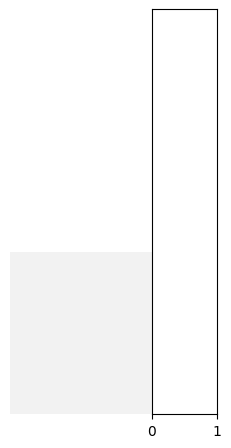

In [28]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# 1) Data preparation, first category is F1A > 0, second category is F1B > 0, etc.
metric_cols = ["F1A", "F1B", "F2A", "F2B", "A1.1", "A1.2", "I1", "I2", "I3", "R1.1", "R1.2", "R1.3"]

memberships = [
    [m for m in metric_cols if row[m] > 0]
    for _, row in df[metric_cols].fillna(0).iterrows()
]

upset_data = from_memberships(memberships)
print(upset_data)

# 3) Tracé
upset = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality")
upset.plot()

plt.suptitle("UpSet Plot of FAIR Dimensions for WorkflowHub Workflows")
plt.savefig("upset_plot_wfhub.png", dpi=300, bbox_inches="tight")
plt.show()
